# Task 1: Air Quality Forecasting — Outputs & Visualizations
Executed using the supplied UCI Air Quality dataset.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
DATA_PATH="/mnt/data/AirQualityUCI_submission.csv"
raw=pd.read_csv(DATA_PATH,sep=None,engine="python")
print("Rows:",raw.shape[0],"Columns:",raw.shape[1])
print("Date range:",raw["Date"].min(),"to",raw["Date"].max())
print("\nMissing-value code (-200):")
print((raw==-200).sum().sort_values(ascending=False).to_string())

Rows: 9357 Columns: 15
Date range: 2004-03-10 to 2005-04-04

Missing-value code (-200):
NMHC(GT)         8443
CO(GT)           1683
NO2(GT)          1642
NOx(GT)          1639
PT08.S2(NMHC)     366
C6H6(GT)          366
PT08.S1(CO)       366
PT08.S5(O3)       366
T                 366
PT08.S3(NOx)      366
PT08.S4(NO2)      366
RH                366
AH                366
Date                0
Time                0


## Descriptive statistics

In [2]:
numeric=raw.select_dtypes(include=np.number).columns
display(raw[numeric].replace(-200,np.nan).describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.153,1.453,0.100,1.100,1.800,2.900,11.900
PT08.S1(CO),8991.0,1099.708,217.085,647.250,936.750,1063.000,1231.250,2039.750
NMHC(GT),914.0,218.812,204.460,7.000,67.000,150.000,297.000,1189.000
C6H6(GT),8991.0,10.083,7.450,0.149,4.437,8.240,13.988,63.741
PT08.S2(NMHC),8991.0,939.029,266.829,383.250,734.375,909.000,1116.250,2214.000
NOx(GT),7718.0,246.881,212.971,2.000,98.000,179.800,326.000,1479.000
PT08.S3(NOx),8991.0,835.371,256.815,322.000,657.875,805.500,969.250,2682.750
NO2(GT),7715.0,113.076,48.359,2.000,78.000,109.000,142.000,339.700
PT08.S4(NO2),8991.0,1456.143,346.205,551.000,1226.625,1462.750,1673.500,2775.000
PT08.S5(O3),8991.0,1022.781,398.481,221.000,731.375,963.250,1273.375,2522.750


In [3]:
df=raw.copy()
df["Datetime"]=pd.to_datetime(df["Date"].astype(str)+" "+df["Time"].astype(str))
df=df.sort_values("Datetime").reset_index(drop=True)
num=df.select_dtypes(include=np.number).columns
df[num]=df[num].replace(-200,np.nan).ffill()
df["hour"]=df["Datetime"].dt.hour
df["day_of_week"]=df["Datetime"].dt.dayofweek
df["month"]=df["Datetime"].dt.month
print("Remaining missing values after causal forward-fill:")
print(df.isna().sum().sort_values(ascending=False).head(10).to_string())

Remaining missing values after causal forward-fill:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0


## Visualization 1 — CO over time

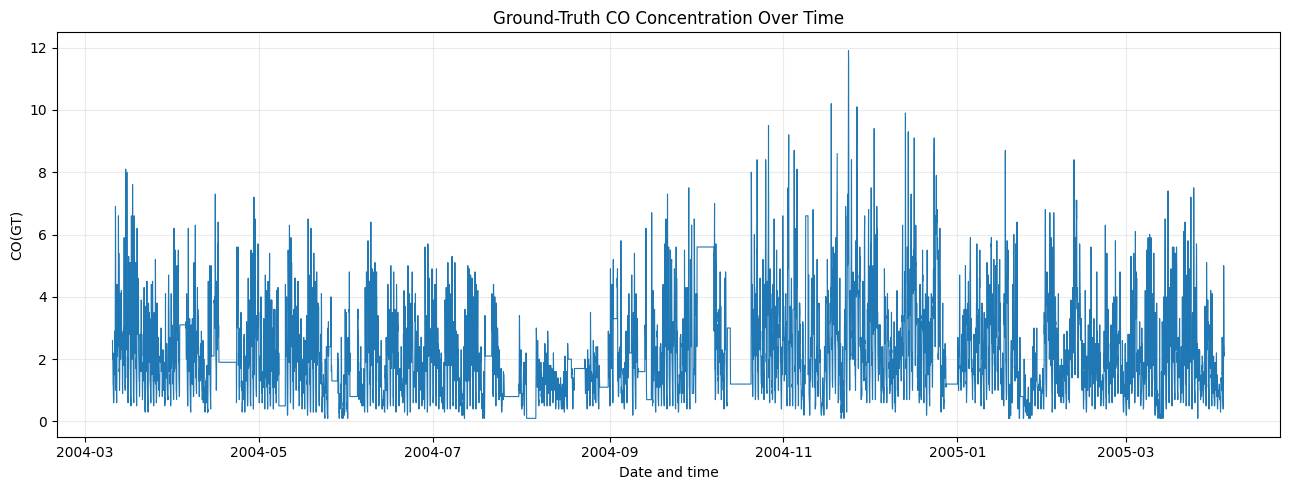

In [4]:
fig,ax=plt.subplots(figsize=(13,5))
ax.plot(df["Datetime"],df["CO(GT)"],linewidth=0.8)
ax.set_title("Ground-Truth CO Concentration Over Time")
ax.set_xlabel("Date and time"); ax.set_ylabel("CO(GT)"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## Visualization 2 — CO distribution

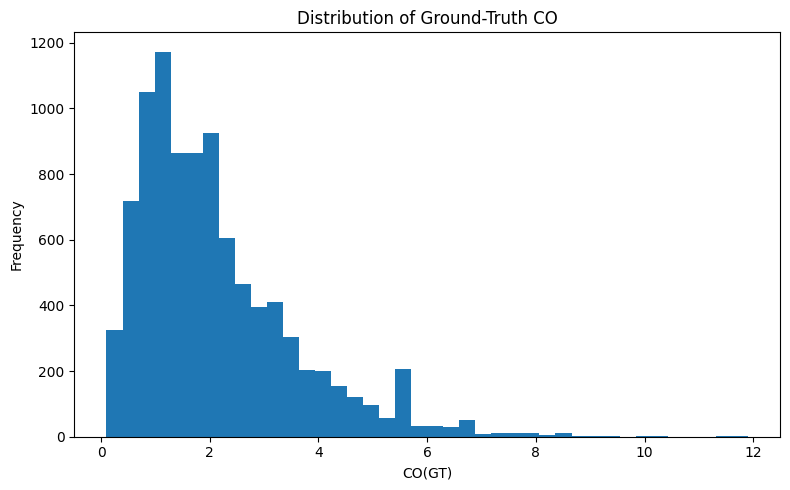

In [5]:
fig,ax=plt.subplots(figsize=(8,5))
ax.hist(df["CO(GT)"].dropna(),bins=40)
ax.set_title("Distribution of Ground-Truth CO"); ax.set_xlabel("CO(GT)"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()

## Visualization 3 — Average CO by hour

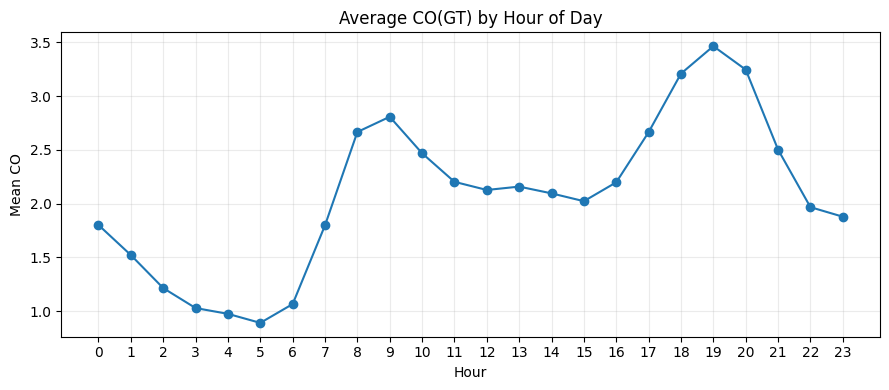

Highest average hour: 19 Mean: 3.464
Lowest average hour: 5 Mean: 0.891


In [6]:
hourly=df.groupby("hour")["CO(GT)"].mean()
fig,ax=plt.subplots(figsize=(9,4))
ax.plot(hourly.index,hourly.values,marker="o")
ax.set_title("Average CO(GT) by Hour of Day"); ax.set_xlabel("Hour"); ax.set_ylabel("Mean CO")
ax.set_xticks(range(24)); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()
print("Highest average hour:",int(hourly.idxmax()),"Mean:",round(hourly.max(),3))
print("Lowest average hour:",int(hourly.idxmin()),"Mean:",round(hourly.min(),3))

## Visualization 4 — Average CO by day of week

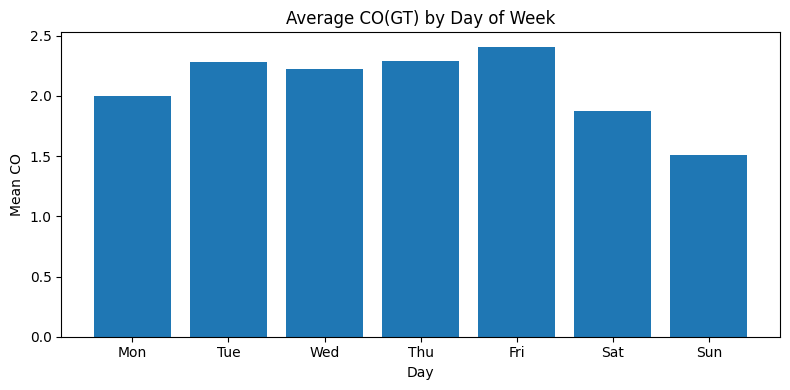

In [7]:
dow=df.groupby("day_of_week")["CO(GT)"].mean()
labels=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig,ax=plt.subplots(figsize=(8,4))
ax.bar(range(7),dow.reindex(range(7)).values)
ax.set_title("Average CO(GT) by Day of Week"); ax.set_xlabel("Day"); ax.set_ylabel("Mean CO")
ax.set_xticks(range(7),labels); plt.tight_layout(); plt.show()

## Visualization 5 — Correlation matrix

CO(GT)      1.000
NOx(GT)     0.788
C6H6(GT)    0.779
NO2(GT)     0.694
RH          0.042
AH          0.023
T           0.001


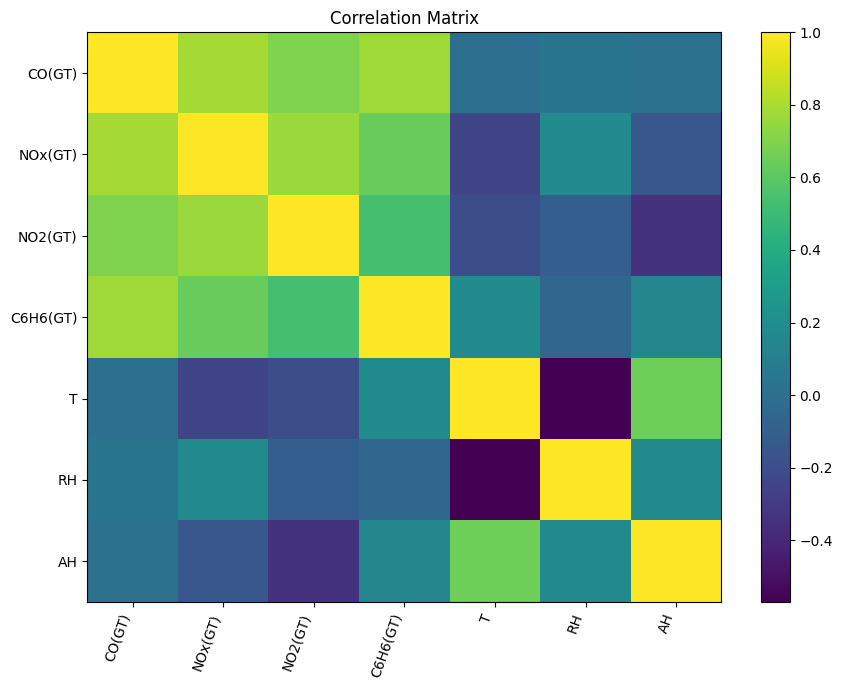

In [8]:
cols=["CO(GT)","NOx(GT)","NO2(GT)","C6H6(GT)","T","RH","AH"]
corr=df[cols].corr()
print(corr["CO(GT)"].sort_values(ascending=False).round(3).to_string())
fig,ax=plt.subplots(figsize=(9,7))
im=ax.imshow(corr,aspect="auto")
ax.set_xticks(range(len(cols)),cols,rotation=70,ha="right")
ax.set_yticks(range(len(cols)),cols); ax.set_title("Correlation Matrix")
plt.colorbar(im,ax=ax); plt.tight_layout(); plt.show()

## Visualization 6 — Monthly average CO

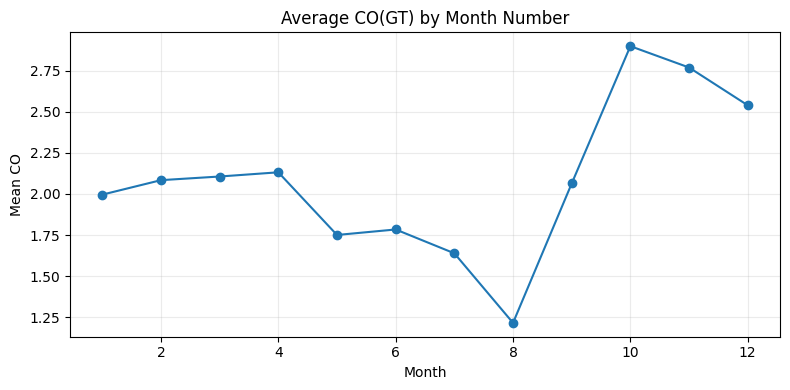

In [9]:
monthly=df.groupby("month")["CO(GT)"].mean()
fig,ax=plt.subplots(figsize=(8,4))
ax.plot(monthly.index,monthly.values,marker="o")
ax.set_title("Average CO(GT) by Month Number"); ax.set_xlabel("Month"); ax.set_ylabel("Mean CO")
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

## Feature engineering output

In [10]:
df["target_next_CO"]=df["CO(GT)"].shift(-1)
for c in ["CO(GT)","NOx(GT)","NO2(GT)","C6H6(GT)","T","RH","AH"]:
    df[f"{c}_lag1"]=df[c].shift(1)
    df[f"{c}_lag3"]=df[c].shift(3)
    df[f"{c}_lag24"]=df[c].shift(24)
for c in ["CO(GT)","NOx(GT)","NO2(GT)","C6H6(GT)"]:
    df[f"{c}_roll3"]=df[c].shift(1).rolling(3).mean()
    df[f"{c}_roll24"]=df[c].shift(1).rolling(24).mean()
display(df[["Datetime","CO(GT)","target_next_CO","CO(GT)_lag1","CO(GT)_lag3","CO(GT)_lag24","CO(GT)_roll3","CO(GT)_roll24","hour","day_of_week","month"]].head(30).round(3))

,Datetime,CO(GT),target_next_CO,CO(GT)_lag1,CO(GT)_lag3,CO(GT)_lag24,CO(GT)_roll3,CO(GT)_roll24,hour,day_of_week,month
0,2004-03-10 18:00:00,2.6,2.0,NaN,NaN,NaN,NaN,NaN,18,2,3
1,2004-03-10 19:00:00,2.0,2.2,2.6,NaN,NaN,NaN,NaN,19,2,3
2,2004-03-10 20:00:00,2.2,2.2,2.0,NaN,NaN,NaN,NaN,20,2,3
3,2004-03-10 21:00:00,2.2,1.6,2.2,2.6,NaN,2.267,NaN,21,2,3
4,2004-03-10 22:00:00,1.6,1.2,2.2,2.0,NaN,2.133,NaN,22,2,3
5,2004-03-10 23:00:00,1.2,1.2,1.6,2.2,NaN,2.000,NaN,23,2,3
6,2004-03-11 00:00:00,1.2,1.0,1.2,2.2,NaN,1.667,NaN,0,3,3
7,2004-03-11 01:00:00,1.0,0.9,1.2,1.6,NaN,1.333,NaN,1,3,3
8,2004-03-11 02:00:00,0.9,0.6,1.0,1.2,NaN,1.133,NaN,2,3,3
9,2004-03-11 03:00:00,0.6,0.6,0.9,1.2,NaN,1.033,NaN,3,3,3
